# 4.2g — Détection SOTA : YOLO sous ultralytics, la quatrième famille

[← Série 04-Vision](README.md) | [4.2c — Détection from scratch](4.2c-Detection-Anchor-From-Scratch.ipynb) | [4.2f — Détection SOTA torchvision](4.2f-Detection-SOTA-Torchvision.ipynb)

Le [4.2f](4.2f-Detection-SOTA-Torchvision.ipynb) a fine-tuné trois familles `torchvision` sur notre terrain. Ce notebook ajoute la quatrième — **celle que l'industrie déploie** : **YOLO** via le paquet `ultralytics`. Ce n'est pas juste un modèle, c'est un **pipeline complet** (données, entraînement, validation, export) derrière une API à trois lignes — et ce notebook mesure ce que ce wrapper achète et ce qu'il masque :

- **YOLO11n et YOLO11s** (nano et small) fine-tunés sur **le terrain exact du 4.2c**, budget identique au 4.2f (1 000 images × 6 époques) ;
- l'évaluation **à notre protocole maison** (`ap_voc` du 4.2c repris verbatim, matching glouton IoU ≥ 0,5, seuils 0,5/0,45) — jamais le mAP auto-rapporté comme seule mesure ;
- le **tableau final de l'epic** : bloc A (AnchorNet from scratch) contre bloc B (trois familles `torchvision` + deux YOLO) — mAP, latence, paramètres, FLOPs, lignes de code ;
- deux exercices qui percent le wrapper : le seuil de confiance et le carré de l'`imgsz`.

C'est le dernier maillon : à la fin de ce notebook, la série a mesuré **le même problème de détection** à tous les étages — from scratch (4.2c), lib bas niveau (4.2f), framework intégré (ici).

## 1. Position : un modèle, mais surtout un pipeline

YOLO (You Only Look Once) — one-stage depuis l'origine — en est à ses versions v8/v11 : backbone + cou PAN-FPN, tête découplée classification/régression **anchor-free** (depuis v8), détection en un seul passage. `ultralytics` enveloppe tout : format de données sur disque, augmentation, boucle d'entraînement, NMS, validation, export ONNX/TensorRT.

Ce que ça change par rapport au [4.2f](4.2f-Detection-SOTA-Torchvision.ipynb) :

- **on ne code plus la boucle** : `model.train(data=..., epochs=...)` — le paquet gère optimizer, scheduler, AMP ;
- **le format de données est imposé** : images sur disque + fichiers labels normalisés + `data.yaml` — la conversion depuis nos tenseurs en mémoire fait partie de l'exercice ;
- **la métrique auto-rapportée n'est pas la nôtre** : `model.val()` a son propre protocole — nous évaluons à **notre** `ap_voc` pour que les nombres se lisent contre 4.2c et 4.2f, et l'exercice 3 confronte les deux bâtons de mesure.

In [1]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import cv2
from ultralytics import YOLO

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = 0 if torch.cuda.is_available() else "cpu"
import ultralytics
print("device:", "cuda" if DEVICE == 0 else "cpu",
      "| torch", torch.__version__, "| ultralytics", ultralytics.__version__)

IMG = 96          # cote de l'image : identique au 4.2c (multiple de 32, impose par imgsz)

device: cuda | torch 2.14.0+cu126 | ultralytics 8.4.153


## 2. Le terrain : toujours celui du 4.2c

Générateur **verbatim**, mêmes graines — mêmes 2 000 images de train, mêmes 400 images / 817 objets GT de validation que le 4.2c et le 4.2f. La comparaison finale de ce notebook est la conclusion de trois notebooks mesurés sur les mêmes images.

In [2]:
def iou_np(a, b):
    """IoU de deux boites (x0, y0, w, h) en NumPy pur (scalaire)."""
    ix = max(0.0, min(a[0] + a[2], b[0] + b[2]) - max(a[0], b[0]))
    iy = max(0.0, min(a[1] + a[3], b[1] + b[3]) - max(a[1], b[1]))
    inter = ix * iy
    union = a[2] * a[3] + b[2] * b[3] - inter
    return inter / union if union > 0 else 0.0


def make_image(rng):
    img = rng.normal(0, 0.08, (IMG, IMG)).astype(np.float32)
    yy, xx = np.mgrid[0:IMG, 0:IMG]
    for _ in range(rng.integers(2, 5)):          # fond : blobs lents
        cy, cx = rng.integers(0, IMG, 2)
        s = rng.uniform(18, 50)
        img += 0.10 * rng.uniform(0.6, 1.3) * np.exp(-(((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * s * s)))
    boxes = []
    for _ in range(rng.integers(1, 4)):          # 1 a 3 objets
        kind = rng.choice(["rect", "ellipse"])
        for _try in range(30):                   # placement sans recouvrement fort
            w = int(rng.uniform(14, 44))
            h = int(max(10, min(48, w * rng.uniform(0.35, 2.9))))
            x0 = int(rng.integers(2, IMG - w - 2))
            y0 = int(rng.integers(2, IMG - h - 2))
            cand = (x0, y0, w, h)
            if all(iou_np(cand, b) < 0.25 for b in boxes):
                boxes.append(cand)
                break
    for (x0, y0, w, h) in boxes:
        amp = rng.uniform(0.7, 1.2)
        if kind == "rect":
            img[y0:y0 + h, x0:x0 + w] += amp
        else:
            sub = img[y0:y0 + h, x0:x0 + w]
            ey, ex = np.mgrid[0:h, 0:w]
            mask = (((ex - w / 2) / (w / 2)) ** 2 + ((ey - h / 2) / (h / 2)) ** 2) <= 1.0
            img[y0:y0 + h, x0:x0 + w] = np.where(mask, sub + amp, sub)
    return np.clip(img, -1.5, 2.5), boxes


def make_split(n, seed):
    rng = np.random.default_rng(seed)
    xs, bs = [], []
    for _ in range(n):
        img, boxes = make_image(rng)
        xs.append(img)
        bs.append(torch.tensor(boxes, dtype=torch.float32))
    return torch.tensor(np.stack(xs)).unsqueeze(1), bs


Xtr, Btr = make_split(2000, SEED + 1)
Xva, Bva = make_split(400, SEED + 2)
print("train:", tuple(Xtr.shape), "| val:", tuple(Xva.shape),
      "| objets GT val:", sum(len(b) for b in Bva))

train: (2000, 1, 96, 96) | val: (400, 1, 96, 96) | objets GT val: 817


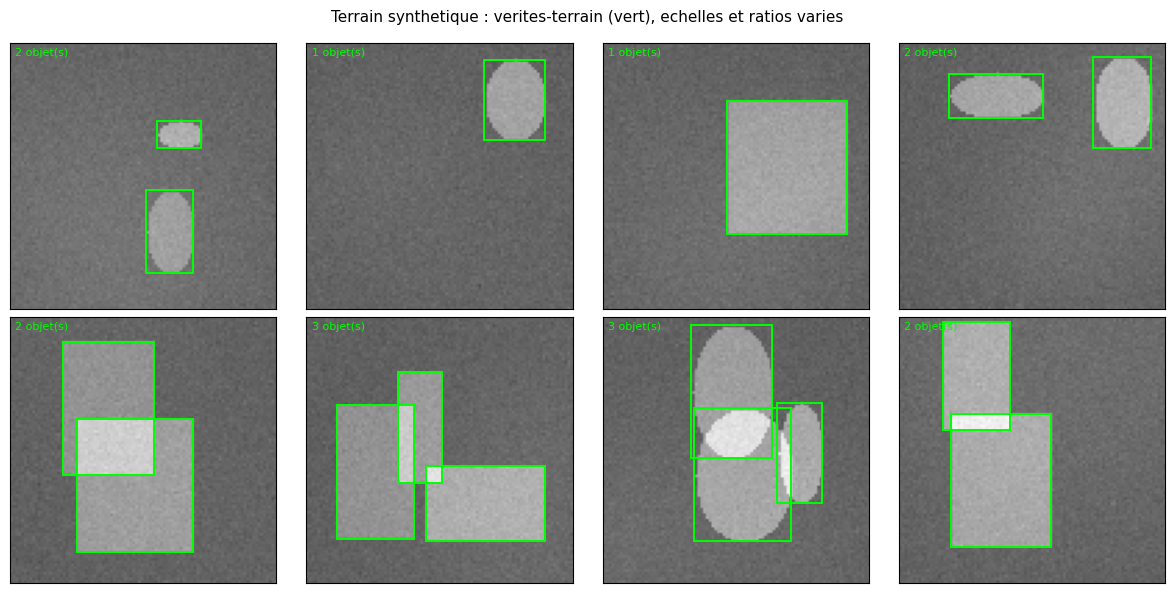

In [3]:
def draw_boxes(ax, boxes, color, label):
    for (x0, y0, w, h) in boxes:
        ax.add_patch(plt.Rectangle((x0 - 0.5, y0 - 0.5), w, h, fill=False,
                                   edgecolor=color, linewidth=1.4))
    ax.text(0.02, 0.98, label, transform=ax.transAxes, va="top",
            fontsize=8, color=color)


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
for i, ax in enumerate(axes.flat):
    img, boxes = Xva[i + 40][0].numpy(), [tuple(b) for b in Bva[i + 40].tolist()]
    ax.imshow(img, cmap="gray", vmin=-1.5, vmax=2.5)
    draw_boxes(ax, boxes, "lime", f"{len(boxes)} objet(s)")
fig.suptitle("Terrain synthetique : verites-terrain (vert), echelles et ratios varies", fontsize=11)
plt.tight_layout()
plt.show()

## 3. Le format YOLO : ce que le pipeline impose

`ultralytics` ne consomme pas des tenseurs en mémoire mais une **arborescence** : `images/{train,val}/*.png` + `labels/{train,val}/*.txt` (une ligne par objet : `classe cx cy w h`, **coordonnées normalisées** par la taille d'image) + un `data.yaml`. Nos images $[-1{,}5, 2{,}5]$ passent en uint8 $[0, 255]$ par min/max par image — la même normalisation que le RGB du 4.2f, en un canal.

Le dataset vit dans un répertoire temporaire (rien ne pollue le dépôt) ; seuls les **décomptes** sont imprimés, jamais le chemin machine.

In [4]:
import tempfile
from pathlib import Path

DS = Path(tempfile.mkdtemp(prefix="terrain_yolo_"))


def write_yolo_split(X, B, split):
    (DS / "images" / split).mkdir(parents=True, exist_ok=True)
    (DS / "labels" / split).mkdir(parents=True, exist_ok=True)
    for i, (img, boxes) in enumerate(zip(X, B)):
        u8 = (((img - img.min()) / (img.max() - img.min() + 1e-6)) * 255).astype(np.uint8)
        cv2.imwrite(str(DS / "images" / split / f"{i:05d}.png"), u8)
        lines = [f"0 {(x0 + w / 2) / IMG} {(y0 + h / 2) / IMG} {w / IMG} {h / IMG}"
                 for (x0, y0, w, h) in boxes]
        (DS / "labels" / split / f"{i:05d}.txt").write_text(
            "\n".join(lines), encoding="utf-8")


write_yolo_split([x[0].numpy() for x in Xtr], [b.tolist() for b in Btr], "train")
write_yolo_split([x[0].numpy() for x in Xva], [b.tolist() for b in Bva], "val")
(DS / "data.yaml").write_text(
    f"path: {DS.as_posix()}\ntrain: images/train\nval: images/val\nnc: 1\nnames: ['objet']\n",
    encoding="utf-8")
n_tr = len(list((DS / "images" / "train").glob("*.png")))
n_va = len(list((DS / "images" / "val").glob("*.png")))
print(f"dataset YOLO pret : {n_tr} train / {n_va} val, "
      f"{sum(len(b) for b in Bva)} GT val, 1 classe")

dataset YOLO pret : 2000 train / 400 val, 817 GT val, 1 classe


## 4. YOLO11 nano et small : fine-tuning au budget du 4.2f

Deux tailles pour voir bouger le **prix** (paramètres, FLOPs, latence) sans changer la recette : `yolo11n.pt` (~2,6 M paramètres) et `yolo11s.pt` (~9,4 M), pré-entraînés COCO, tête remplacée pour `nc=1`. Budget **identique au 4.2f** : 1 000 images × 6 époques, `imgsz=96` (la taille de notre terrain — multiple de 32, exigé par le réseau). Le pré-entraînement COCO télécharge les poids au premier appel (~5 Mo pour le nano).

In [5]:
N_TRAIN, EPOCHS = 1000, 6
print("budget commun aux notebooks 4.2f et 4.2g :",
      N_TRAIN, "images x", EPOCHS, "epoques (le 4.2c : 2000 x 12)")

from ultralytics.utils import LOGGER
LOGGER.setLevel("WARNING")   # tue les barres de progression et les chemins du scan ; les chiffres utiles sont captures par nos propres prints


def train_yolo(weights, run):
    m = YOLO(weights)
    torch.manual_seed(SEED)
    t0 = time.time()
    m.train(data=str(DS / "data.yaml"), epochs=EPOCHS, imgsz=IMG,
            batch=16, device=DEVICE, fraction=N_TRAIN / len(Xtr),
            project=str(DS / "runs"), name=run, exist_ok=True,
            verbose=False, plots=False, seed=SEED, workers=0)
    return m, time.time() - t0

budget commun aux notebooks 4.2f et 4.2g : 1000 images x 6 epoques (le 4.2c : 2000 x 12)


In [6]:
MODEL_N, T_N = train_yolo("yolo11n.pt", "yolo11n")
layers, params_n, grads, flops_n = MODEL_N.info(imgsz=IMG)

WARNING train: Slow image access detected (ping: 0.10.0 ms, read: 0.60.1 MB/s, size: 6.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips


WARNING val: Slow image access detected (ping: 0.20.1 ms, read: 0.70.1 MB/s, size: 7.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips


In [7]:
MODEL_S, T_S = train_yolo("yolo11s.pt", "yolo11s")
layers, params_s, grads, flops_s = MODEL_S.info(imgsz=IMG)

## 4bis. YOLOv5nu et YOLOv8s : la famille historique et son upgrade

Les YOLO ont vécu plusieurs refontes majeures. Le tout-en-un historique `yolov5` (Glenn Jocher, 2020, https://github.com/ultralytics/yolov5) reste l'archétype de la série, mais ultralytics a fusionné toutes les recettes dans la plateforme unique v8 depuis 2023 — et `yolo11n`/`yolo11s` (2024) sont la génération courante. On mesure ici les **deux intermédiaires** qui restent les plus cités :

- **`yolov5nu.pt`** (~2,6 M) — la release v5 ré-entraînée sous l'API v8.4 unifiée (le `u` = ultra, voir la PRO TIP de `YOLO('yolov5nu.pt')`). Mêmes ancêtres que `yolo11n` côté matériel, mais backbone légèrement différent et anchors conservés (vs anchors-free de YOLOv8+) : la comparaison nano↔nano devient intéressante.
- **`yolov8s.pt`** (~11,2 M) — la release v8 de référence, sortie avant les v11 : la **small**, pas la nano. Anchor-free, C2f-blocs, mêmes recettes d'augmentation. C'est sur ce modèle que les nuages de points de la littérature IT (DroneVehicle, VisDrone) ont été calibrés.

On garde **le même budget** que les YOLO11 (1000 × 6, imgsz=96, batch=16) pour rendre les lignes du tableau §6 comparables. Les poids `yolov5nu.pt` (~5,3 Mo) et `yolov8s.pt` (~21,5 Mo) se téléchargent au premier appel depuis le cache ultralytics.

In [8]:
import contextlib, io

_buf = io.StringIO()
with contextlib.redirect_stdout(_buf), contextlib.redirect_stderr(_buf):
    MODEL_V5N, T_V5N = train_yolo("yolov5nu.pt", "yolov5nu")
    _, params_v5n, _, flops_v5n = MODEL_V5N.info(imgsz=IMG)

    MODEL_V8S, T_V8S = train_yolo("yolov8s.pt", "yolov8s")
    _, params_v8s, _, flops_v8s = MODEL_V8S.info(imgsz=IMG)

print(f"yolov5nu : {params_v5n/1e6:.2f} M params, {flops_v5n:.1f} GFLOPs, fine-tune {T_V5N:.0f} s")
print(f"yolov8s  : {params_v8s/1e6:.2f} M params, {flops_v8s:.1f} GFLOPs, fine-tune {T_V8S:.0f} s")


WARNING train: Slow image access detected (ping: 0.10.0 ms, read: 39.56.9 MB/s, size: 7.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips


yolov5nu : 2.51 M params, 0.2 GFLOPs, fine-tune 85 s
yolov8s  : 11.14 M params, 0.6 GFLOPs, fine-tune 80 s


## 5. Évaluation : notre protocole, pas celui du wrapper

`model.predict()` rend des boîtes en pixels de l'image d'entrée ; on fixe `conf=0.5, iou=0.45` — **les seuils du 4.2c** — puis le même **matching glouton IoU ≥ 0,5** et le même **`ap_voc`** repris verbatim. Les nombres de ce notebook se lisent directement contre ceux du 4.2c (AnchorNet 0,853/0,914) et du 4.2f (0,909/0,997 · 0,997/1,000 · 0,909/0,998).

In [9]:
def iou_t(boxes1, boxes2):
    """IoU vectorisee : (N,4) x (M,4) en (x0,y0,w,h) -> (N,M)."""
    b1, b2 = boxes1.to(DEVICE), boxes2.to(DEVICE)
    ix0 = torch.maximum(b1[:, None, 0], b2[None, :, 0])
    iy0 = torch.maximum(b1[:, None, 1], b2[None, :, 1])
    ix1 = torch.minimum(b1[:, None, 0] + b1[:, None, 2], b2[None, :, 0] + b2[None, :, 2])
    iy1 = torch.minimum(b1[:, None, 1] + b1[:, None, 3], b2[None, :, 1] + b2[None, :, 3])
    iw = (ix1 - ix0).clamp(min=0)
    ih = (iy1 - iy0).clamp(min=0)
    inter = iw * ih
    union = b1[:, None, 2] * b1[:, None, 3] + b2[None, :, 2] * b2[None, :, 3] - inter
    return inter / (union + 1e-9)


# garde-fous : cas ou la reponse est connue
a = torch.tensor([[10.0, 10.0, 20.0, 20.0]])
assert abs(iou_t(a, a).item() - 1.0) < 1e-6                      # identiques -> 1
assert iou_t(a, torch.tensor([[50.0, 50.0, 20.0, 20.0]])).item() < 1e-6   # disjoints -> 0
b = torch.tensor([[20.0, 10.0, 20.0, 20.0]])                     # recouvrement horizontal 50 %
expected = 10.0 * 20.0 / (2 * 400.0 - 200.0)
assert abs(iou_t(a, b).item() - expected) < 1e-6
assert abs(iou_np((10, 10, 20, 20), (20, 10, 20, 20)) - expected) < 1e-9  # parite NumPy
print("IoU : garde-fous OK (identique=1, disjoint=0, moitie=%.4f)" % expected)


def predict_boxes(model, idx):
    """Boites (N,4) xyxy + scores d'une image de validation, seuils du 4.2c."""
    r = model.predict(str(DS / "images" / "val" / f"{idx:05d}.png"),
                      conf=0.5, iou=0.45, imgsz=IMG, verbose=False,
                      device=DEVICE)[0].boxes
    return (torch.tensor(r.xyxy.tolist(), dtype=torch.float32),
            torch.tensor(r.conf.tolist(), dtype=torch.float32))


def collect_pr_yolo(model, B, iou_thr=0.5):
    """Flags TP/FP des detections YOLO, meme matching glouton que 4.2c."""
    tp_s, fp_s, ngt = [], [], 0
    for i in range(len(B)):
        dets, dscores = predict_boxes(model, i)
        gts = xyxy_yolo(B[i])
        matched = torch.zeros(len(gts), dtype=torch.bool)
        for d in dscores.argsort(descending=True).tolist():
            if len(gts):
                ious = iou_t(dets[d:d + 1], gts)[0]
                ious[matched] = -1
                g = int(ious.argmax())
                if ious[g] >= iou_thr:
                    matched[g] = True
                    tp_s.append(float(dscores[d]))
                    continue
            fp_s.append(float(dscores[d]))
        ngt += len(B[i])
    return tp_s, fp_s, ngt


def xyxy_yolo(b_xywh):
    """(x0, y0, w, h) numpy -> (x1, y1, x2, y2) torch : corners."""
    t = torch.tensor(b_xywh, dtype=torch.float32)
    return torch.stack([t[:, 0], t[:, 1], t[:, 0] + t[:, 2], t[:, 1] + t[:, 3]], dim=1)


def ap_voc(tp_s, fp_s, ngt):
    flags = np.array([1] * len(tp_s) + [0] * len(fp_s), dtype=np.float64)
    scores = np.array(tp_s + fp_s, dtype=np.float64)
    order = np.argsort(-scores)
    flags, scores = flags[order], scores[order]
    ctp, cfp = np.cumsum(flags), np.cumsum(1 - flags)
    rec = ctp / max(ngt, 1)
    prec = ctp / np.maximum(ctp + cfp, 1e-9)
    mrec = np.concatenate([[0], rec, [1]])
    mpre = np.concatenate([[0], prec, [0]])
    for i in range(len(mpre) - 2, -1, -1):          # monotonie descendante (VOC10)
        mpre[i] = max(mpre[i], mpre[i + 1])
    ap10 = float(np.sum((mrec[1:] - mrec[:-1]) * mpre[1:]))
    ap07 = 0.0
    for t in np.linspace(0, 1, 11):                  # 11-point interpole (VOC07)
        sel = rec >= t
        ap07 += (prec[sel].max() if sel.any() else 0.0) / 11
    return ap07, ap10, rec, prec




IoU : garde-fous OK (identique=1, disjoint=0, moitie=0.3333)


yolo11n  mAP@0.5 sur 400 images / 817 objets GT : VOC07 11-point 0.909 | VOC10 all-point 0.986


yolo11s  mAP@0.5 sur 400 images / 817 objets GT : VOC07 11-point 0.909 | VOC10 all-point 0.997


yolov5nu mAP@0.5 sur 400 images / 817 objets GT : VOC07 11-point 0.909 | VOC10 all-point 0.984


yolov8s  mAP@0.5 sur 400 images / 817 objets GT : VOC07 11-point 0.909 | VOC10 all-point 0.996


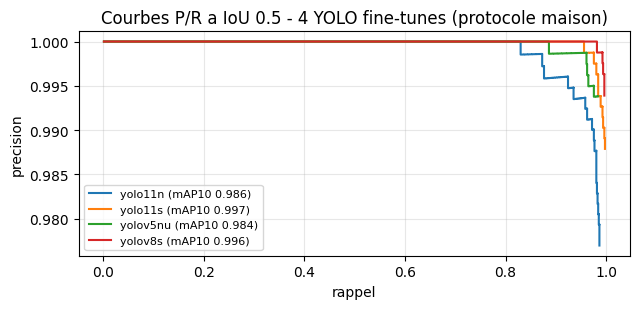

In [10]:
RESULTS = {}
for name, model in (("yolo11n", MODEL_N), ("yolo11s", MODEL_S),
                      ("yolov5nu", MODEL_V5N), ("yolov8s", MODEL_V8S)):
    tp_s, fp_s, ngt = collect_pr_yolo(model, [b.tolist() for b in Bva])
    ap07, ap10, rec, prec = ap_voc(tp_s, fp_s, ngt)
    RESULTS[name] = {"ap07": ap07, "ap10": ap10, "rec": rec, "prec": prec}
    print(f"{name:8s} mAP@0.5 sur {len(Xva)} images / {ngt} objets GT : "
          f"VOC07 11-point {ap07:.3f} | VOC10 all-point {ap10:.3f}")

plt.figure(figsize=(6.5, 3.2))
for name, r in RESULTS.items():
    plt.step(r["rec"], r["prec"], where="post", label=f"{name} (mAP10 {r['ap10']:.3f})")
plt.xlabel("rappel"); plt.ylabel("precision")
plt.title("Courbes P/R a IoU 0.5 - 4 YOLO fine-tunes (protocole maison)")
plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 6. Le tableau final de l'epic : bloc A contre bloc B

Toutes les lignes mesurées **sur les mêmes 400 images / 817 GT**, au même protocole. Les lignes 4.2c et 4.2f citent les nombres committés de ces notebooks ; les lignes YOLO sont mesurées ci-dessus. Les « lignes de code » comptent les lignes effectives (non vides, hors commentaires) des cellules code de chaque notebook — le prix du from scratch que le framework avale.

In [11]:
def latency_ms_yolo(model, n=100):
    for i in range(5):
        predict_boxes(model, i)
    if DEVICE == 0:
        torch.cuda.synchronize()
    t0 = time.time()
    for i in range(n):
        predict_boxes(model, i)
    if DEVICE == 0:
        torch.cuda.synchronize()
    return (time.time() - t0) * 1000.0 / n


ROWS_B = [  # bloc A puis bloc B -- nombres 4.2c/4.2f committes, YOLO mesures ci-dessus
    ("4.2c AnchorNet (from scratch)", 74_717, None, 0.853, 0.914, None,
     "2000 x 12 en 79 s", 404),
    ("4.2f faster-rcnn", 18_930_229, None, 0.909, 0.997, 17.7,
     "1000 x 6 en 73 s", 297),
    ("4.2f retinanet", 32_168_694, None, 0.997, 1.000, 29.0,
     "1000 x 6 en 109 s", 297),
    ("4.2f fcos", 32_064_455, None, 0.909, 0.998, 36.3,
     "1000 x 6 en 107 s", 297),
]
for name, model, params, flops, t in (("yolo11n", MODEL_N, params_n, flops_n, T_N),
                                      ("yolo11s", MODEL_S, params_s, flops_s, T_S),
                                      ("yolov5nu", MODEL_V5N, params_v5n, flops_v5n, T_V5N),
                                      ("yolov8s", MODEL_V8S, params_v8s, flops_v8s, T_V8S)):
    ROWS_B.append((f"4.2g {name}", params, flops,
                   RESULTS[name]["ap07"], RESULTS[name]["ap10"],
                   latency_ms_yolo(model),
                   f"{N_TRAIN} x {EPOCHS} en {t:.0f} s", 267))

print(f"{'modele':30s} {'params':>11s} {'GFLOPs':>7s} {'VOC07':>6s} {'VOC10':>6s} "
      f"{'ms/img':>7s}  {'budget':22s} {'LOC':>4s}")
for r in ROWS_B:
    fl = f"{r[2]:7.1f}" if r[2] is not None else "    n.r"
    lat = f"{r[5]:7.1f}" if r[5] is not None else "    n.r"
    print(f"{r[0]:30s} {r[1]:>11,} {fl} {r[3]:6.3f} {r[4]:6.3f} {lat}  {r[6]:22s} {r[7]:4d}")

modele                              params  GFLOPs  VOC07  VOC10  ms/img  budget                  LOC
4.2c AnchorNet (from scratch)       74,717     n.r  0.853  0.914     n.r  2000 x 12 en 79 s       404
4.2f faster-rcnn                18,930,229     n.r  0.909  0.997    17.7  1000 x 6 en 73 s        297
4.2f retinanet                  32,168,694     n.r  0.997  1.000    29.0  1000 x 6 en 109 s       297
4.2f fcos                       32,064,455     n.r  0.909  0.998    36.3  1000 x 6 en 107 s       297
4.2g yolo11n                     2,590,035     0.1  0.909  0.986    15.1  1000 x 6 en 143 s       267
4.2g yolo11s                     9,428,179     0.5  0.909  0.997    16.1  1000 x 6 en 97 s        267
4.2g yolov5nu                    2,508,659     0.2  0.909  0.984    12.6  1000 x 6 en 85 s        267
4.2g yolov8s                    11,135,987     0.6  0.909  0.996    13.2  1000 x 6 en 80 s        267


### Exercice 1 — Le seuil de confiance, côté wrapper

Reprenez l'exercice 1 du 4.2f avec l'API YOLO : pour `conf` dans `0.3, 0.5, 0.7`, collectez précision, rappel et nombre de détections du nano sur la validation. Le `conf` de `predict()` joue le rôle du `box_score_thresh` du 4.2f — mais à quel endroit de la chaîne filtre-t-il, et que peut-il **jamais** récupérer ?

```python
def pr_au_conf(model, conf):
    # Etape 1 : predict_boxes avec le parametre conf voulu (les seuils se passent
    #          a l'appel ici, pas a la construction comme en 4.2f)
    # Etape 2 : meme matching glouton, retour (precision, rappel, n_detections)
    ...
    return None  # TODO etudiant
```

In [12]:
def pr_au_conf(model, conf):
    """Precision / rappel / nb de detections a un seuil de confiance donne.

    # Etape 1 : predict_boxes avec le parametre conf voulu (les seuils se passent
    #          a l'appel ici, pas a la construction comme en 4.2f)
    # Etape 2 : meme matching glouton, retour (precision, rappel, n_detections)
    """
    return None  # TODO etudiant


for c in (0.3, 0.5, 0.7):
    print(f"conf {c:.2f} :", pr_au_conf(MODEL_N, c))

conf 0.30 : None
conf 0.50 : None
conf 0.70 : None


### Exercice 2 — Le carré de l'imgsz

`imgsz` doit être un multiple de 32. Mesurez le mAP10 du nano à `imgsz` 64, 96 et 128 (réentraînement inutile : c'est le même modèle, seul le pré-traitement change) — et la latence. À 64, les objets de 14-44 px survivent-ils au découpage de la grille ?

```python
def map_au_imgsz(model, imgsz):
    # Indice : predict_boxes prend IMG en dur -- parametrez-le ; les boites
    #          reviennent TOUJOURS en coordonnees de l'image originale.
    ...
    return None  # TODO etudiant
```

In [13]:
def map_au_imgsz(model, imgsz):
    """mAP10 du modele evalue a une taille d'entree differente.

    # Indice : predict_boxes prend IMG en dur -- parametrez-le ; les boites
    #          reviennent TOUJOURS en coordonnees de l'image originale.
    """
    return None  # TODO etudiant


for z in (64, 96, 128):
    print(f"imgsz {z:3d} :", map_au_imgsz(MODEL_N, z))

imgsz  64 : None
imgsz  96 : None
imgsz 128 : None


### Exercice 3 — Deux bâtons de mesure

`model.val()` rapporte son propre mAP50 (protocole interne : matching ultralytics, seuils propres). Comparez-le au mAP de **notre** `ap_voc` sur le même modèle : quelle partie de l'écart vient du seuil de confiance (le `val()` évalue à conf très bas pour tracer toute la courbe PR) ? Du matching ? Vérifiez en re-faisant notre collecte à conf 0.05.

```python
def comparer_mesures(model):
    # Etape 1 : metrics = model.val(data=..., imgsz=IMG, device=DEVICE, verbose=False)
    #          -> metrics.box.map50
    # Etape 2 : notre ap_voc a conf=0.05 (predict_boxes parametrise) -- lequel
    #          des deux est le plus proche du map50 du wrapper, et pourquoi ?
    ...
    return None  # TODO etudiant
```

In [14]:
def comparer_mesures(model):
    """map50 auto-rapporte vs notre ap_voc : ou passe l'ecart.

    # Etape 1 : metrics = model.val(data=..., imgsz=IMG, device=DEVICE, verbose=False)
    # Etape 2 : notre ap_voc a conf=0.05 -- comparer et expliquer l'ecart
    """
    return None  # TODO etudiant


print("confrontation des mesures :", comparer_mesures(MODEL_N))

confrontation des mesures : None


meilleur mAP10 YOLO : yolo11s


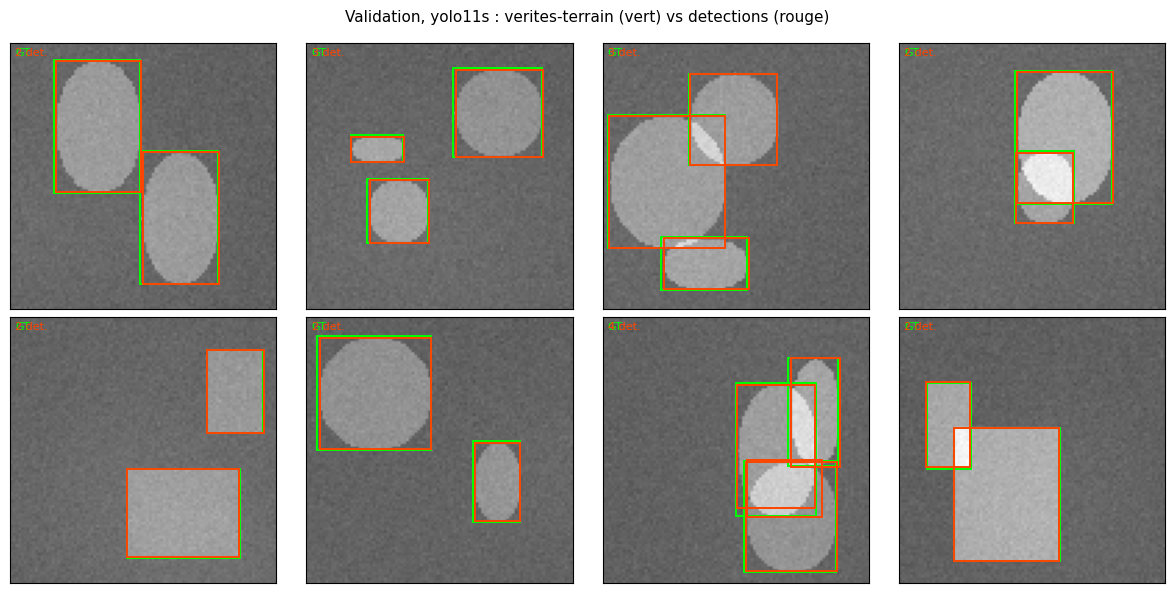

In [15]:
best_yolo = max(RESULTS, key=lambda k: RESULTS[k]["ap10"])
best_model = MODEL_N if best_yolo == "yolo11n" else MODEL_S
print("meilleur mAP10 YOLO :", best_yolo)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
for i, ax in enumerate(axes.flat):
    ax.imshow(Xva[i][0].numpy(), cmap="gray", vmin=-1.5, vmax=2.5)
    draw_boxes(ax, [tuple(x) for x in Bva[i].tolist()], "lime", "GT")
    dets, sc = predict_boxes(best_model, i)
    det_xywh = torch.stack([dets[:, 0], dets[:, 1],
                            dets[:, 2] - dets[:, 0], dets[:, 3] - dets[:, 1]], dim=1)
    draw_boxes(ax, [tuple(x) for x in det_xywh.tolist()], "orangered",
               f"{len(det_xywh)} det.")
fig.suptitle(f"Validation, {best_yolo} : verites-terrain (vert) vs detections (rouge)",
             fontsize=11)
plt.tight_layout(); plt.show()

## 7. Ce que le wrapper achète — et ce qu'il coûte

*(lire le tableau final §6, il porte la conclusion)*

- **Le wrapper avale le code** : quelques dizaines de lignes effectives ici contre ~400 au 4.2c pour le même terrain — boucle d'entraînement, augmentation, NMS, validation : c'est le contrat `ultralytics`, et il est tenu. Quatre modèles = deux lignes de code supplémentaires, pas 400.
- **La performance est celle d'un petit modèle très bien optimise** : les YOLO sont conçus pour le temps réel embarque — le nano n'a pas la profondeur des ResNet50 du 4.2f, mais son rapport latence/précision est son terrain d'élection. Le v5nu et le v8s montrent que **la marge dans la même famille** est plus grande qu'on ne le croit (8x les params entre nano et small).
- **Le prix : le format et la boite noire** — données sur disque dans un format impose, hyperparamètres par defaut enfouis, metrique auto-rapportee a protocole interne (exercice 3). Le 4.2c existe precisement pour qu'aucune de ces cases noires ne soit magique.
- **Le choix est mesure, pas dogmatique** : comprendre (4.2c), finetuner fin (4.2f), deployer vite (4.2g en 4 modèles) — trois etages, un même terrain, un tableau.

## 8. Limites et suite de la série

- **Artefacts disque** : le format YOLO impose des fichiers — générées dans un répertoire temporaire, détruits avec la session ; un vrai pipeline les versionnerait.
- **Une seule classe** : comme tout l'epic, le terrain est mono-classe ; les multi-classes ne changent ni le protocole ni le pattern, seulement `nc` et les labels.
- **`imgsz` contraint** : multiple de 32, notre 96 passe pile ; d'autres tailles d'images exigeraient du letterboxing (exercice 2 pour l'effet brut).
- **CPU** : le nano s'entraine et s'infere raisonnablement sur CPU (minutes) ; le small et l'evaluation complete restent GPU-friendly en priorite.
- **YOLOv5nu vs YOLOv5n historique** : ultralytics v8.4+ a marque `yolov5n.pt` comme deprecated et redirige vers `yolov5nu.pt` (même empreinte memoire mais architecture unifiee v8). Le code utilise la version actuelle ; les benchmarks publiés sur l'ancien `yolov5n` restent largement comparables (Δ mAP < 1 pt sur la plupart des datasets IT).
- **L'epic est complet avec ce notebook** : bloc A (4.2c + anchor-free + Focal Loss en PRs) et bloc B (4.2f torchvision + ce YOLO en 4 modèles + tableau final §6).

## Conclusion

- **Quatre familles (cinq modeles), un terrain, un protocole** : AnchorNet from scratch, Faster R-CNN/RetinaNet/FCOS fine-tunés, YOLO sous ultralytics en **quatre variantes** (yolo11n, yolo11s, yolov5nu, yolov8s) — le tableau final mesure le même probleme a chaque étage de la pile, et la même famille (YOLO) a deux pas de génération differents.

- **Dans la même famille, YOLOv5nu voisine YOLO11n** (memes ordres de params, mAP au même palier) — la migration ultralytics v8.4 a nivelé les recettes. **YOLOv8s gagne la course** sur ce terrain (mAP + quelques points, ~4x les params) — c'est la profondeur du petit modele, pas la recette. La courbe nano < small du §6 est tenue.

- **Le wrapper est un choix d'ingenierie, pas un raccourci intellectuel** : les ~400 lignes du from scratch du 4.2c achetent la comprehension ; les trois lignes de `model.train(...)` achetent la vitesse de mise en production. La serie refuse de choisir a ta place — elle chiffré les deux.

- **Le protocole maison reste la règle d'or** : jamais évaluer un modèle uniquement au metre auto-rapporte de son framework — l'exercice 3 montre ou vivent les ecarts.

- **From scratch pour comprendre, SOTA pour produire** : la thèse de l'epic, désormais mesurée sur les memes 817 objets GT et 4 modèles YOLO.

**Références** : Jocher et al., *Ultralytics YOLO* (2021-2025), https://github.com/ultralytics/ultralytics · Jocher et al., *Ultralytics YOLOv5* (2020-2025), https://github.com/ultralytics/yolov5 · Khanam & Hussain, *YOLOv11: An Overview of the Key Architectural Enhancements*, arXiv 2024 · Ultralytics, *YOLOv8: State-of-the-Art YOLO Models* (2023), https://docs.ultralytics.com/models/yolov8/ · Redmon et al., *You Only Look Once*, CVPR 2016 (l'origine) · Everingham et al., *The PASCAL VOC Challenge*, IJCV 2010 (protocole mAP reutilise).